  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


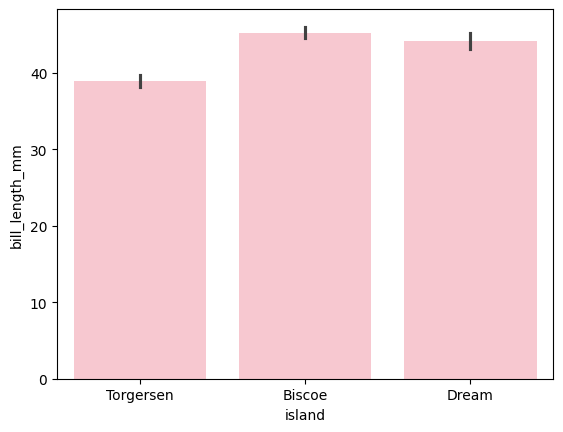

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
penguins=sns.load_dataset("penguins")
print(penguins.head(5))

#task1
sns.barplot(data=penguins, x="island", y="bill_length_mm", color='pink')
plt.show()


<Axes: xlabel='island', ylabel='count'>

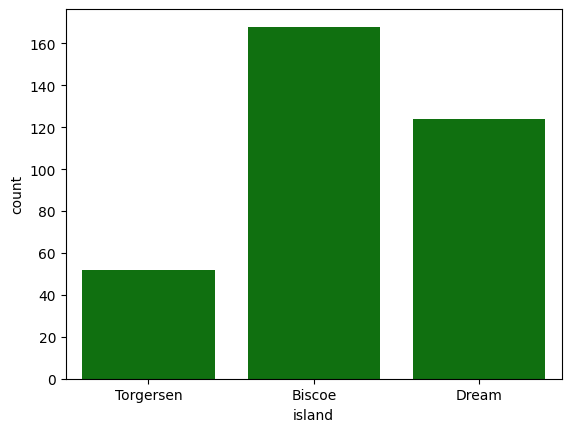

In [31]:
#task2
sns.countplot(data=penguins, x="island", color='green')

<Axes: xlabel='bill_depth_mm', ylabel='Count'>

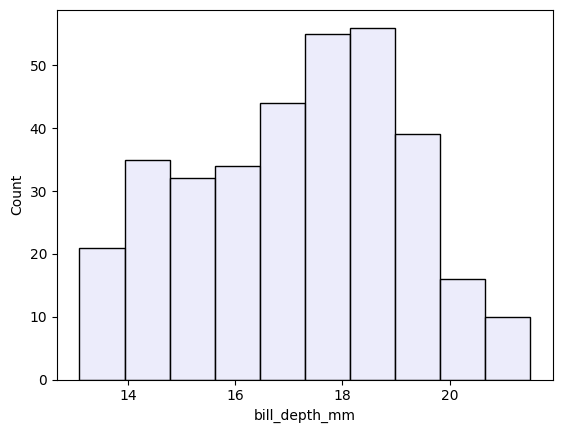

In [50]:
#task3
sns.histplot(data=penguins, x="bill_depth_mm", color='lavender')

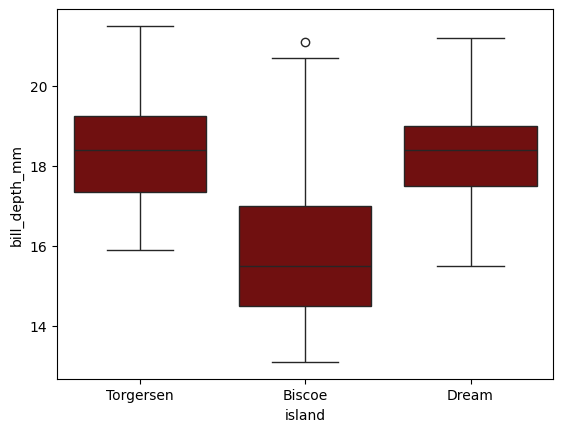

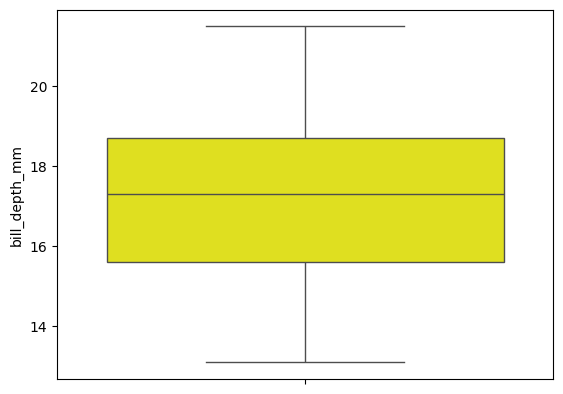

In [51]:
#task4
sns.boxplot(data=penguins, x="island", y="bill_depth_mm", color='maroon')
plt.show()
sns.boxplot(data=penguins, y="bill_depth_mm", color='yellow')
plt.show()

In [45]:
#task5
q1=penguins['bill_depth_mm'].quantile(0.25)
q3=penguins['bill_depth_mm'].quantile(0.75)
iqr=q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers= penguins[(penguins['bill_depth_mm'] < lower) | (penguins['bill_depth_mm'] > upper)]
print(len(outliers))

#according to island column

q1_island = penguins.groupby('island')['bill_depth_mm'].transform('quantile', 0.25)

q3_island = penguins.groupby('island')['bill_depth_mm'].transform('quantile', 0.75)

iqr_island = q3_island - q1_island
lower_island = q1_island - 1.5 * iqr_island
upper_island = q3_island + 1.5 * iqr_island
outlierss = penguins[(penguins['bill_depth_mm'] < lower_island) | (penguins['bill_depth_mm'] > upper_island)
]
#give that Q1 to every penguin from that island
print(len(outlierss))

0
1


yes they match. the visual boxplot gives same answer as the mathematic outlier calculation

In [49]:
#task6
from scipy import stats
penguins['zscore']= stats.zscore(penguins['bill_length_mm'])
outliers_z = penguins[penguins['zscore'].abs()< 3]
print(len(outliers_z))

0


iqr is with respect to median and z score is with respect too mean and distribution is skewed


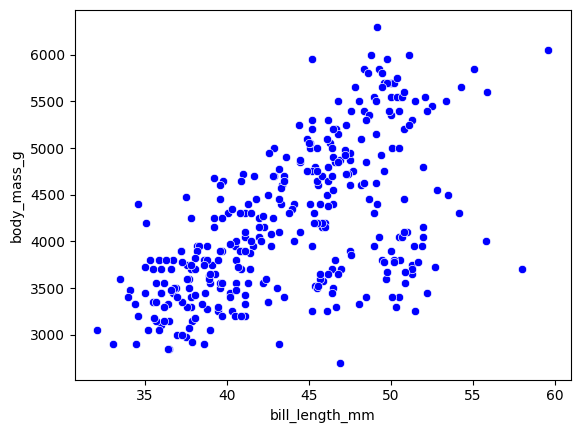

In [53]:
#task7
sns.scatterplot(data=penguins, x="bill_length_mm", y="body_mass_g", color='blue')
plt.show()


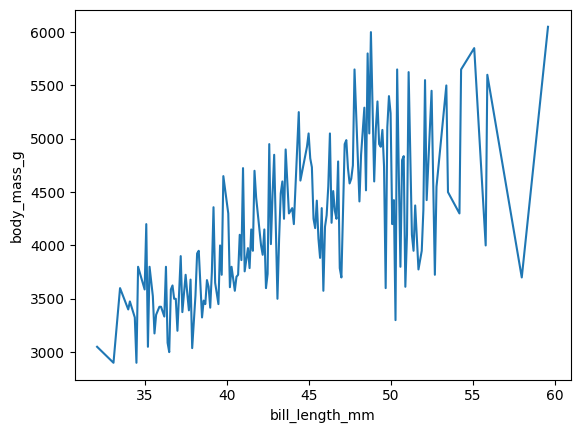

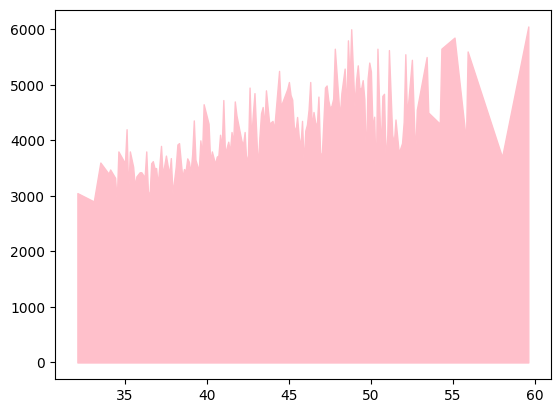

In [61]:
#task8
aa=penguins.groupby('bill_length_mm')['body_mass_g'].mean().reset_index()
sns.lineplot(data=aa, x="bill_length_mm", y="body_mass_g")
plt.show()
plt.fill_between(aa['bill_length_mm'], aa['body_mass_g'], color='pink')
plt.show()


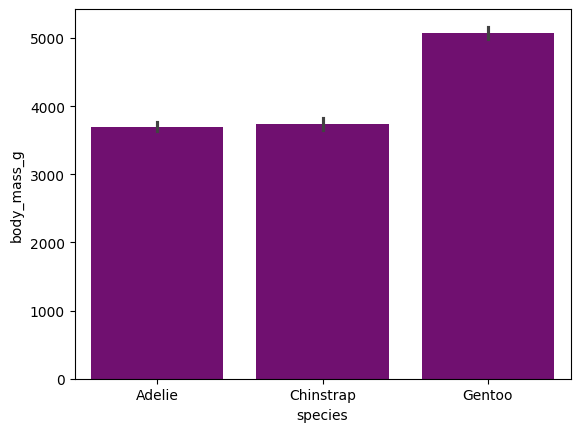

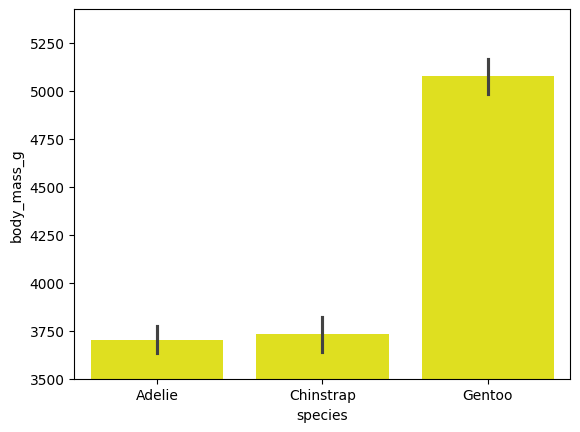

In [59]:
#task9
sns.barplot(data=penguins, x='species', y='body_mass_g', color='purple')
plt.ylim(0)
plt.show()

sns.barplot(data=penguins, x='species', y='body_mass_g', color='yellow')
plt.ylim(3500)
plt.show()

visually the truncated chart makes the data look large, and misleading
